In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
lloyds_main = pd.read_excel("Llyods.xlsx", sheet_name= None)

In [3]:
customer_demographics = lloyds_main["Customer_Demographics"]

In [4]:
len(customer_demographics)

1000

In [5]:
customer_demographics.head(6)

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium
5,6,57,F,Divorced,Medium


In [6]:
transaction_history = lloyds_main["Transaction_History"]

In [7]:
len(transaction_history)

5054

In [8]:
transaction_history.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [9]:
customer_service = lloyds_main["Customer_Service"]

In [10]:
len(customer_service)

1002

In [11]:
customer_service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [12]:
online_activity = lloyds_main["Online_Activity"]

In [13]:
len(online_activity)

1000

In [14]:
online_activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [15]:
churn_status = lloyds_main["Churn_Status"]

In [16]:
len(churn_status)

1000

In [17]:
churn_status.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [18]:
print(customer_demographics.isna().sum(), transaction_history.isna().sum(), customer_service.isna().sum(), online_activity.isna().sum(), churn_status.isna().sum())

CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64 CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64 CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64 CustomerID        0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
dtype: int64 CustomerID     0
ChurnStatus    0
dtype: int64


Merging the Churn Status and the Online Activity together

In [19]:
customer_activity = online_activity.merge(churn_status, on="CustomerID", how="left")

In [20]:
customer_activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,2023-10-21,34,Mobile App,0
1,2,2023-12-05,5,Website,1
2,3,2023-11-15,3,Website,0
3,4,2023-08-25,2,Website,0
4,5,2023-10-27,41,Website,0


In [21]:
customer_information = customer_activity.merge(customer_demographics, on="CustomerID", how="left")

In [22]:
customer_information.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel
0,1,2023-10-21,34,Mobile App,0,62,M,Single,Low
1,2,2023-12-05,5,Website,1,65,M,Married,Low
2,3,2023-11-15,3,Website,0,18,M,Single,Low
3,4,2023-08-25,2,Website,0,21,M,Widowed,Low
4,5,2023-10-27,41,Website,0,21,M,Divorced,Medium


In [23]:
customer_service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


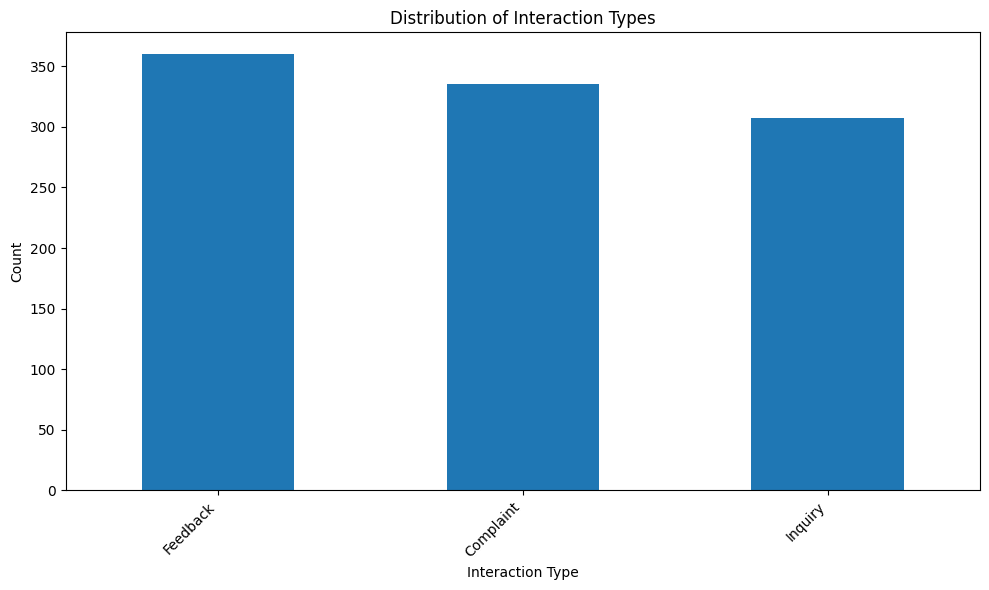

In [24]:
interaction_type_counts = customer_service['InteractionType'].value_counts()

plt.figure(figsize=(10, 6))
interaction_type_counts.plot(kind='bar')
plt.title('Distribution of Interaction Types')
plt.xlabel('Interaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

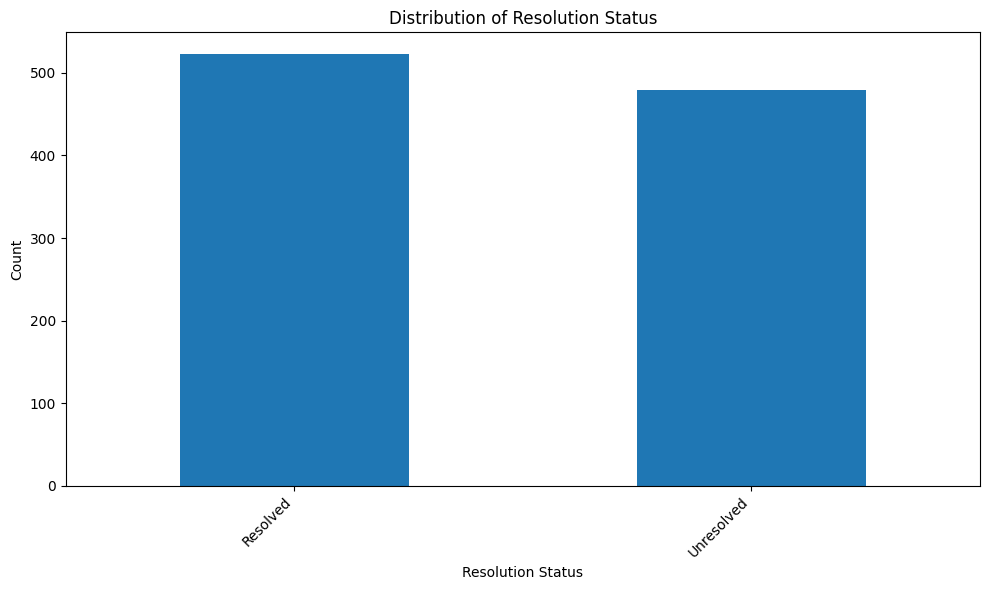

In [25]:
interaction_type_counts = customer_service['ResolutionStatus'].value_counts()

plt.figure(figsize=(10, 6))
interaction_type_counts.plot(kind='bar')
plt.title('Distribution of Resolution Status')
plt.xlabel('Resolution Status')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [26]:
transaction_history.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


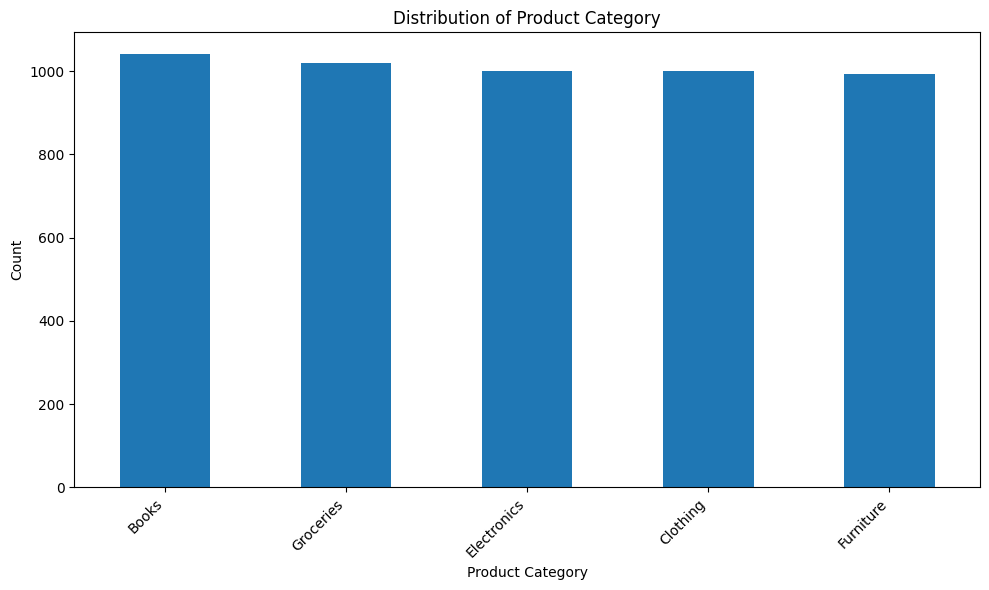

In [27]:
product_category_counts = transaction_history['ProductCategory'].value_counts()

plt.figure(figsize=(10, 6))
product_category_counts.plot(kind='bar')
plt.title('Distribution of Product Category')
plt.xlabel('Product Category')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [28]:
transaction_history.TransactionDate.dtype

dtype('<M8[ns]')

I would have to change the resolution status to binary. I have to remember to do that in my pipeline. Resolved is 1 and Unresolved is 0

Now lets update customer service

In [29]:
customer_service.ResolutionStatus = customer_service.ResolutionStatus.map({"Resolved":1, "Unresolved":0})

In [30]:
customer_service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,1
1,2,3329,2022-03-17,Inquiry,1
2,3,9976,2022-08-24,Inquiry,1
3,4,7354,2022-11-18,Inquiry,1
4,4,5393,2022-07-03,Inquiry,0


In [31]:
customer_service.groupby("CustomerID").agg(NumberOfResolved=("ResolutionStatus","count")).columns

Index(['NumberOfResolved'], dtype='object')

In [32]:
# Get unique interaction types from the customer_service DataFrame
interaction_types = customer_service['InteractionType'].unique()

# Initialize an empty DataFrame to store the aggregated counts, starting with unique CustomerIDs
customer_service_agg = pd.DataFrame({'CustomerID': customer_service['CustomerID'].unique()})

# Iterate through each interaction type to calculate resolved and unresolved counts
for interaction_type in interaction_types:
    # Filter customer_service for the current interaction type
    df_filtered_by_type = customer_service[customer_service['InteractionType'] == interaction_type]

    # Calculate resolved counts for the current interaction type
    resolved_counts = df_filtered_by_type[df_filtered_by_type['ResolutionStatus'] == 1] \
        .groupby('CustomerID').size().reset_index(name=f'{interaction_type}Resolved')
    customer_service_agg = customer_service_agg.merge(resolved_counts, on='CustomerID', how='left')

    # Calculate unresolved counts for the current interaction type
    unresolved_counts = df_filtered_by_type[df_filtered_by_type['ResolutionStatus'] == 0] \
        .groupby('CustomerID').size().reset_index(name=f'{interaction_type}Unresolved')
    customer_service_agg = customer_service_agg.merge(unresolved_counts, on='CustomerID', how='left')

# Fill NaN values (for customers who had no interactions of a certain type or resolution status) with 0
customer_service_agg = customer_service_agg.fillna(0)

# Convert the count columns to integer type for clarity
for col in customer_service_agg.columns:
    if col != 'CustomerID':
        customer_service_agg[col] = customer_service_agg[col].astype(int)

for interaction_type in interaction_types:
    customer_service_agg[f'{interaction_type}Total'] = customer_service_agg[f'{interaction_type}Resolved'] + customer_service_agg[f'{interaction_type}Unresolved']

# Select only the CustomerID, Resolved counts, and Total counts
columns_to_keep = ['CustomerID']
for interaction_type in interaction_types:
    columns_to_keep.append(f'{interaction_type}Resolved')
    columns_to_keep.append(f'{interaction_type}Total')

customer_service_agg = customer_service_agg[columns_to_keep]

In [33]:
customer_service_agg

,CustomerID,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal
0,1,1,1,0,0,0,0
1,2,1,1,0,0,0,0
2,3,1,1,0,0,0,0
3,4,1,2,0,0,0,0
4,6,0,0,1,1,0,0
...,...,...,...,...,...,...,...
663,989,0,0,0,0,0,2
664,990,0,0,1,1,0,1
665,992,0,0,0,1,0,0
666,994,0,0,0,0,0,2


In [34]:
most_recent_interaction_per_customer = customer_service.loc[customer_service.groupby('CustomerID')['InteractionDate'].idxmax()]

# Select CustomerID and the MostRecentInteractionType
most_recent_interaction_type = most_recent_interaction_per_customer[['CustomerID', 'InteractionType']].rename(columns={'InteractionType': 'MostRecentInteractionType'})

# Merge this information into the customer_service_agg DataFrame
customer_service_agg = customer_service_agg.merge(
    most_recent_interaction_type,
    on='CustomerID',
    how='left'
)

print("Customer service aggregate with most recent interaction type:")
print(customer_service_agg.head())

Customer service aggregate with most recent interaction type:
   CustomerID  InquiryResolved  InquiryTotal  FeedbackResolved  FeedbackTotal  \
0           1                1             1                 0              0   
1           2                1             1                 0              0   
2           3                1             1                 0              0   
3           4                1             2                 0              0   
4           6                0             0                 1              1   

   ComplaintResolved  ComplaintTotal MostRecentInteractionType  
0                  0               0                   Inquiry  
1                  0               0                   Inquiry  
2                  0               0                   Inquiry  
3                  0               0                   Inquiry  
4                  0               0                  Feedback  


In [35]:
customer_service_agg

,CustomerID,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,MostRecentInteractionType
0,1,1,1,0,0,0,0,Inquiry
1,2,1,1,0,0,0,0,Inquiry
2,3,1,1,0,0,0,0,Inquiry
3,4,1,2,0,0,0,0,Inquiry
4,6,0,0,1,1,0,0,Feedback
...,...,...,...,...,...,...,...,...
663,989,0,0,0,0,0,2,Complaint
664,990,0,0,1,1,0,1,Complaint
665,992,0,0,0,1,0,0,Feedback
666,994,0,0,0,0,0,2,Complaint


In [36]:
# Calculate the most recent interaction date for each customer
most_recent_interaction_date_per_customer = customer_service.groupby('CustomerID')['InteractionDate'].max().reset_index()
most_recent_interaction_date_per_customer = most_recent_interaction_date_per_customer.rename(columns={'InteractionDate': 'MostRecentInteractionDate'})

# Calculate the overall latest interaction date to use as reference
reference_date = customer_service['InteractionDate'].max()

# Calculate days since the most recent interaction for each customer
most_recent_interaction_date_per_customer['DaysSinceMostRecentInteraction'] = \
    (reference_date - most_recent_interaction_date_per_customer['MostRecentInteractionDate']).dt.days

# Merge this information into the customer_service_agg DataFrame
customer_service_agg = customer_service_agg.merge(
    most_recent_interaction_date_per_customer[['CustomerID', 'DaysSinceMostRecentInteraction']],
    on='CustomerID',
    how='left'
)

In [37]:
customer_service_agg

,CustomerID,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,MostRecentInteractionType,DaysSinceMostRecentInteraction
0,1,1,1,0,0,0,0,Inquiry,274
1,2,1,1,0,0,0,0,Inquiry,288
2,3,1,1,0,0,0,0,Inquiry,128
3,4,1,2,0,0,0,0,Inquiry,42
4,6,0,0,1,1,0,0,Feedback,239
...,...,...,...,...,...,...,...,...,...
663,989,0,0,0,0,0,2,Complaint,84
664,990,0,0,1,1,0,1,Complaint,66
665,992,0,0,0,1,0,0,Feedback,92
666,994,0,0,0,0,0,2,Complaint,181


In [38]:
customer_information = customer_information.merge(customer_service_agg, on = "CustomerID", how= "left")

In [39]:
customer_information.isna().sum()

,0
CustomerID,0
LastLoginDate,0
LoginFrequency,0
ServiceUsage,0
ChurnStatus,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
InquiryResolved,332


In [40]:
customer_information[["InquiryResolved","InquiryTotal","FeedbackResolved","FeedbackTotal","ComplaintResolved","ComplaintTotal"]] = customer_information[["InquiryResolved","InquiryTotal","FeedbackResolved","FeedbackTotal","ComplaintResolved","ComplaintTotal"]].fillna(0)

In [41]:
customer_information["DaysSinceMostRecentInteraction"].fillna(999,inplace=True)

/tmp/ipykernel_8563/1964641324.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  customer_information["DaysSinceMostRecentInteraction"].fillna(999,inplace=True)


In [42]:
customer_information["MostRecentInteractionType"] = customer_information["MostRecentInteractionType"].fillna("NoInteraction")

In [43]:
customer_information

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,MostRecentInteractionType,DaysSinceMostRecentInteraction
0,1,2023-10-21,34,Mobile App,0,62,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,Inquiry,274.0
1,2,2023-12-05,5,Website,1,65,M,Married,Low,1.0,1.0,0.0,0.0,0.0,0.0,Inquiry,288.0
2,3,2023-11-15,3,Website,0,18,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,Inquiry,128.0
3,4,2023-08-25,2,Website,0,21,M,Widowed,Low,1.0,2.0,0.0,0.0,0.0,0.0,Inquiry,42.0
4,5,2023-10-27,41,Website,0,21,M,Divorced,Medium,0.0,0.0,0.0,0.0,0.0,0.0,NoInteraction,999.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-01-29,38,Mobile App,0,54,F,Single,Low,0.0,0.0,0.0,0.0,0.0,0.0,NoInteraction,999.0
996,997,2023-04-01,5,Mobile App,0,19,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,NoInteraction,999.0
997,998,2023-07-10,47,Website,0,47,M,Married,Low,0.0,0.0,0.0,0.0,0.0,0.0,NoInteraction,999.0
998,999,2023-01-08,23,Website,0,23,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,NoInteraction,999.0


In [44]:
customer_information = pd.get_dummies(customer_information, columns=["MostRecentInteractionType"], prefix="LastType", drop_first=True,dtype=int)

In [45]:
customer_information

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction
0,1,2023-10-21,34,Mobile App,0,62,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0
1,2,2023-12-05,5,Website,1,65,M,Married,Low,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0
2,3,2023-11-15,3,Website,0,18,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0
3,4,2023-08-25,2,Website,0,21,M,Widowed,Low,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0
4,5,2023-10-27,41,Website,0,21,M,Divorced,Medium,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-01-29,38,Mobile App,0,54,F,Single,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1
996,997,2023-04-01,5,Mobile App,0,19,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1
997,998,2023-07-10,47,Website,0,47,M,Married,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1
998,999,2023-01-08,23,Website,0,23,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1


Now let me work on the transaction history

In [46]:
transaction_history.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [47]:
transaction_agg = transaction_history.copy()

In [48]:
# Calculate total amount spent for each customer ID
total_spent_per_customer = transaction_agg.groupby('CustomerID')['AmountSpent'].sum().reset_index(name='TotalAmountSpent')

In [49]:
total_spent_per_customer.head()

,CustomerID,TotalAmountSpent
0,1,416.50
1,2,1547.42
2,3,1702.98
3,4,917.29
4,5,2001.49


In [50]:
# Calculate average spend per transaction
average_spend_per_transaction = transaction_agg.groupby('CustomerID')['AmountSpent'].mean().reset_index(name='AverageSpendPerTransaction')

In [51]:
average_spend_per_transaction.head()

,CustomerID,AverageSpendPerTransaction
0,1,416.50000
1,2,221.06000
2,3,283.83000
3,4,183.45800
4,5,250.18625


In [52]:
# Calculate spending frequency (number of transactions)
spending_frequency = transaction_agg.groupby('CustomerID').size().reset_index(name='SpendingFrequency')

In [53]:
spending_frequency.head()

,CustomerID,SpendingFrequency
0,1,1
1,2,7
2,3,6
3,4,5
4,5,8


In [54]:
# Calculate number of unique categories purchased
num_categories = transaction_agg.groupby('CustomerID')['ProductCategory'].nunique().reset_index(name='NumberOfCategories')

In [55]:
num_categories.head()

,CustomerID,NumberOfCategories
0,1,1
1,2,4
2,3,4
3,4,4
4,5,3


In [56]:
latest_overall_transaction_date = transaction_agg['TransactionDate'].max()

# Get the last transaction date for each customer
last_transaction_date_per_customer = transaction_agg.groupby('CustomerID')['TransactionDate'].max().reset_index()
last_transaction_date_per_customer.rename(columns={'TransactionDate': 'LastTransactionDate'}, inplace=True)

# Calculate days since last transaction
last_transaction_date_per_customer['DaysSinceLastTransaction'] = (latest_overall_transaction_date - last_transaction_date_per_customer['LastTransactionDate']).dt.days

In [57]:
# Merge all aggregated features into a single DataFrame
transaction_features = total_spent_per_customer
transaction_features = transaction_features.merge(average_spend_per_transaction, on='CustomerID', how='left')
transaction_features = transaction_features.merge(spending_frequency, on='CustomerID', how='left')
transaction_features = transaction_features.merge(num_categories, on='CustomerID', how='left')
transaction_features = transaction_features.merge(last_transaction_date_per_customer[['CustomerID', 'DaysSinceLastTransaction']], on='CustomerID', how='left')

In [58]:
transaction_features.head()

,CustomerID,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction
0,1,416.50,416.50000,1,1,279
1,2,1547.42,221.06000,7,4,42
2,3,1702.98,283.83000,6,4,84
3,4,917.29,183.45800,5,4,4
4,5,2001.49,250.18625,8,3,10


In [63]:
customer_information = customer_information.merge(transaction_features, on="CustomerID", how="left")

In [64]:
customer_information.isna().sum()

,0
CustomerID,0
LastLoginDate,0
LoginFrequency,0
ServiceUsage,0
ChurnStatus,0
Age,0
Gender,0
MaritalStatus,0
IncomeLevel,0
InquiryResolved,0


In [65]:
customer_information.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,...,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction
0,1,2023-10-21,34,Mobile App,0,62,M,Single,Low,1.0,...,0.0,274.0,0,1,0,416.50,416.50000,1,1,279
1,2,2023-12-05,5,Website,1,65,M,Married,Low,1.0,...,0.0,288.0,0,1,0,1547.42,221.06000,7,4,42
2,3,2023-11-15,3,Website,0,18,M,Single,Low,1.0,...,0.0,128.0,0,1,0,1702.98,283.83000,6,4,84
3,4,2023-08-25,2,Website,0,21,M,Widowed,Low,1.0,...,0.0,42.0,0,1,0,917.29,183.45800,5,4,4
4,5,2023-10-27,41,Website,0,21,M,Divorced,Medium,0.0,...,0.0,999.0,0,0,1,2001.49,250.18625,8,3,10


In [66]:
# Determine the most recent login date to use as a reference point
reference_date_login = customer_information['LastLoginDate'].max()

# Calculate DaysSinceLastLogin
customer_information['DaysSinceLastLogin'] = (reference_date_login - customer_information['LastLoginDate']).dt.days

In [69]:
pd.set_option('display.max_columns', None)

In [70]:
customer_information

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction,DaysSinceLastLogin
0,1,2023-10-21,34,Mobile App,0,62,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0,416.50,416.500000,1,1,279,71
1,2,2023-12-05,5,Website,1,65,M,Married,Low,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0,1547.42,221.060000,7,4,42,26
2,3,2023-11-15,3,Website,0,18,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0,1702.98,283.830000,6,4,84,46
3,4,2023-08-25,2,Website,0,21,M,Widowed,Low,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0,917.29,183.458000,5,4,4,128
4,5,2023-10-27,41,Website,0,21,M,Divorced,Medium,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2001.49,250.186250,8,3,10,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-01-29,38,Mobile App,0,54,F,Single,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,227.25,227.250000,1,1,160,336
996,997,2023-04-01,5,Mobile App,0,19,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,419.82,209.910000,2,2,67,274
997,998,2023-07-10,47,Website,0,47,M,Married,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,252.15,252.150000,1,1,104,174
998,999,2023-01-08,23,Website,0,23,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2393.26,265.917778,9,4,24,357


In [71]:
customer_final = customer_information.copy()

In [72]:
customer_final

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction,DaysSinceLastLogin
0,1,2023-10-21,34,Mobile App,0,62,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0,416.50,416.500000,1,1,279,71
1,2,2023-12-05,5,Website,1,65,M,Married,Low,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0,1547.42,221.060000,7,4,42,26
2,3,2023-11-15,3,Website,0,18,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0,1702.98,283.830000,6,4,84,46
3,4,2023-08-25,2,Website,0,21,M,Widowed,Low,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0,917.29,183.458000,5,4,4,128
4,5,2023-10-27,41,Website,0,21,M,Divorced,Medium,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2001.49,250.186250,8,3,10,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-01-29,38,Mobile App,0,54,F,Single,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,227.25,227.250000,1,1,160,336
996,997,2023-04-01,5,Mobile App,0,19,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,419.82,209.910000,2,2,67,274
997,998,2023-07-10,47,Website,0,47,M,Married,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,252.15,252.150000,1,1,104,174
998,999,2023-01-08,23,Website,0,23,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2393.26,265.917778,9,4,24,357


In [75]:
customer_final.drop("LastLoginDate", axis=1, inplace=True)

In [76]:
customer_final

,CustomerID,LoginFrequency,ServiceUsage,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction,DaysSinceLastLogin
0,1,34,Mobile App,0,62,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0,416.50,416.500000,1,1,279,71
1,2,5,Website,1,65,M,Married,Low,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0,1547.42,221.060000,7,4,42,26
2,3,3,Website,0,18,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0,1702.98,283.830000,6,4,84,46
3,4,2,Website,0,21,M,Widowed,Low,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0,917.29,183.458000,5,4,4,128
4,5,41,Website,0,21,M,Divorced,Medium,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2001.49,250.186250,8,3,10,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,38,Mobile App,0,54,F,Single,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,227.25,227.250000,1,1,160,336
996,997,5,Mobile App,0,19,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,419.82,209.910000,2,2,67,274
997,998,47,Website,0,47,M,Married,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,252.15,252.150000,1,1,104,174
998,999,23,Website,0,23,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2393.26,265.917778,9,4,24,357


Text(0, 0.5, 'Count')

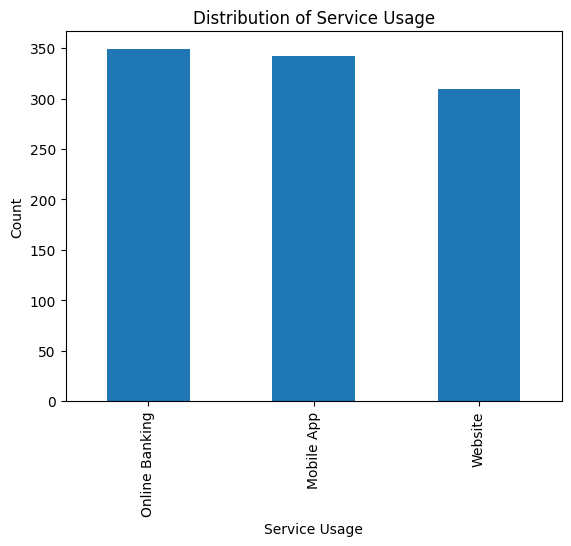

In [77]:
service_counts = customer_final.ServiceUsage.value_counts()
service_counts.plot(kind='bar')
plt.title('Distribution of Service Usage')
plt.xlabel('Service Usage')
plt.ylabel('Count')

In [78]:
customer_service_usage = pd.get_dummies(customer_final, columns=["ServiceUsage"], prefix="ServiceType", drop_first=True,dtype=int)

In [79]:
customer_service_usage

,CustomerID,LoginFrequency,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction,DaysSinceLastLogin,ServiceType_Online Banking,ServiceType_Website
0,1,34,0,62,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0,416.50,416.500000,1,1,279,71,0,0
1,2,5,1,65,M,Married,Low,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0,1547.42,221.060000,7,4,42,26,0,1
2,3,3,0,18,M,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0,1702.98,283.830000,6,4,84,46,0,1
3,4,2,0,21,M,Widowed,Low,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0,917.29,183.458000,5,4,4,128,0,1
4,5,41,0,21,M,Divorced,Medium,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2001.49,250.186250,8,3,10,65,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,38,0,54,F,Single,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,227.25,227.250000,1,1,160,336,0,0
996,997,5,0,19,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,419.82,209.910000,2,2,67,274,0,0
997,998,47,0,47,M,Married,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,252.15,252.150000,1,1,104,174,0,1
998,999,23,0,23,M,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2393.26,265.917778,9,4,24,357,0,1


Text(0, 0.5, 'Count')

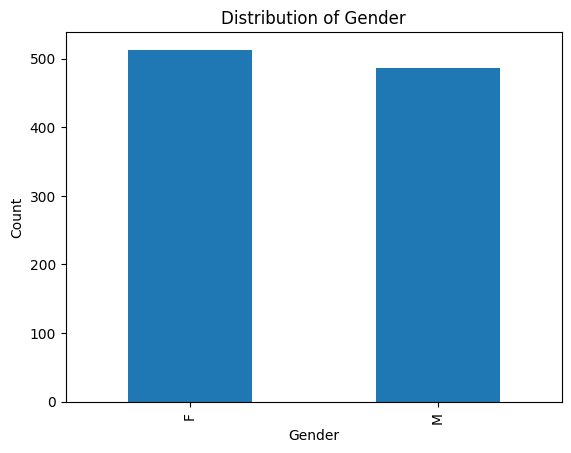

In [80]:
gender_counts = customer_service_usage.Gender.value_counts()
gender_counts.plot(kind='bar')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

In [81]:
customer_service_usage['Gender'] = customer_service_usage['Gender'].map({'M': 0, 'F': 1})

In [82]:
customer_service_usage

,CustomerID,LoginFrequency,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction,DaysSinceLastLogin,ServiceType_Online Banking,ServiceType_Website
0,1,34,0,62,0,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0,416.50,416.500000,1,1,279,71,0,0
1,2,5,1,65,0,Married,Low,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0,1547.42,221.060000,7,4,42,26,0,1
2,3,3,0,18,0,Single,Low,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0,1702.98,283.830000,6,4,84,46,0,1
3,4,2,0,21,0,Widowed,Low,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0,917.29,183.458000,5,4,4,128,0,1
4,5,41,0,21,0,Divorced,Medium,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2001.49,250.186250,8,3,10,65,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,38,0,54,1,Single,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,227.25,227.250000,1,1,160,336,0,0
996,997,5,0,19,0,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,419.82,209.910000,2,2,67,274,0,0
997,998,47,0,47,0,Married,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,252.15,252.150000,1,1,104,174,0,1
998,999,23,0,23,0,Widowed,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2393.26,265.917778,9,4,24,357,0,1


In [83]:
customer_final = pd.get_dummies(customer_service_usage, columns=["MaritalStatus"], prefix="MaritalType", drop_first=True,dtype=int)

In [84]:
customer_final

,CustomerID,LoginFrequency,ChurnStatus,Age,Gender,IncomeLevel,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction,DaysSinceLastLogin,ServiceType_Online Banking,ServiceType_Website,MaritalType_Married,MaritalType_Single,MaritalType_Widowed
0,1,34,0,62,0,Low,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0,416.50,416.500000,1,1,279,71,0,0,0,1,0
1,2,5,1,65,0,Low,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0,1547.42,221.060000,7,4,42,26,0,1,1,0,0
2,3,3,0,18,0,Low,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0,1702.98,283.830000,6,4,84,46,0,1,0,1,0
3,4,2,0,21,0,Low,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0,917.29,183.458000,5,4,4,128,0,1,0,0,1
4,5,41,0,21,0,Medium,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2001.49,250.186250,8,3,10,65,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,38,0,54,1,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,227.25,227.250000,1,1,160,336,0,0,0,1,0
996,997,5,0,19,0,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,419.82,209.910000,2,2,67,274,0,0,0,0,1
997,998,47,0,47,0,Low,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,252.15,252.150000,1,1,104,174,0,1,1,0,0
998,999,23,0,23,0,High,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2393.26,265.917778,9,4,24,357,0,1,0,0,1


Text(0, 0.5, 'Count')

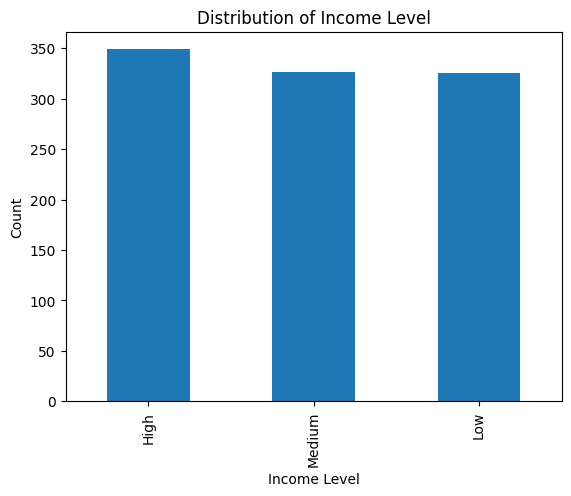

In [85]:
income_counts = customer_final.IncomeLevel.value_counts()
income_counts.plot(kind='bar')
plt.title('Distribution of Income Level')
plt.xlabel('Income Level')
plt.ylabel('Count')

In [87]:
customer_final = pd.get_dummies(customer_final, columns=["IncomeLevel"], prefix="IncomeType", drop_first=True,dtype=int)

In [88]:
customer_final

,CustomerID,LoginFrequency,ChurnStatus,Age,Gender,InquiryResolved,InquiryTotal,FeedbackResolved,FeedbackTotal,ComplaintResolved,ComplaintTotal,DaysSinceMostRecentInteraction,LastType_Feedback,LastType_Inquiry,LastType_NoInteraction,TotalAmountSpent,AverageSpendPerTransaction,SpendingFrequency,NumberOfCategories,DaysSinceLastTransaction,DaysSinceLastLogin,ServiceType_Online Banking,ServiceType_Website,MaritalType_Married,MaritalType_Single,MaritalType_Widowed,IncomeType_Low,IncomeType_Medium
0,1,34,0,62,0,1.0,1.0,0.0,0.0,0.0,0.0,274.0,0,1,0,416.50,416.500000,1,1,279,71,0,0,0,1,0,1,0
1,2,5,1,65,0,1.0,1.0,0.0,0.0,0.0,0.0,288.0,0,1,0,1547.42,221.060000,7,4,42,26,0,1,1,0,0,1,0
2,3,3,0,18,0,1.0,1.0,0.0,0.0,0.0,0.0,128.0,0,1,0,1702.98,283.830000,6,4,84,46,0,1,0,1,0,1,0
3,4,2,0,21,0,1.0,2.0,0.0,0.0,0.0,0.0,42.0,0,1,0,917.29,183.458000,5,4,4,128,0,1,0,0,1,1,0
4,5,41,0,21,0,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2001.49,250.186250,8,3,10,65,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,38,0,54,1,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,227.25,227.250000,1,1,160,336,0,0,0,1,0,1,0
996,997,5,0,19,0,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,419.82,209.910000,2,2,67,274,0,0,0,0,1,0,0
997,998,47,0,47,0,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,252.15,252.150000,1,1,104,174,0,1,1,0,0,1,0
998,999,23,0,23,0,0.0,0.0,0.0,0.0,0.0,0.0,999.0,0,0,1,2393.26,265.917778,9,4,24,357,0,1,0,0,1,0,0
